# OSRS money makers — top earners over time

Dataset: [nicapotato/osrs-money-makers](https://www.kaggle.com/datasets/nicapotato/osrs-money-makers) (`methods.parquet`, `input_output.parquet`, partitioned `snapshots/` and `prices/`).

**Grain:** one row per **method × calendar day** after collapsing intraday wiki scrapes. Snapshot fields include `rank`, `hourly_profit_gp`, `gp_per_completion`, and `completions_per_hour`. GE price partitions track `price`, `volume`, quartiles, and `price_variance` per `item_id`.

**Objective:** identify which money-making methods **lead the leaderboard**, how **hourly profit and rank shift** day-over-day, and which **input/output item prices** move alongside the biggest profit swings.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from kagglehub import KaggleDatasetAdapter
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "legend.fontsize": 10,
    }
)

DATA_SLUG = "nicapotato/osrs-money-makers"
METHODS_FILE = "methods.parquet"
IO_FILE = "input_output.parquet"
SNAPSHOTS_DIR = "snapshots"
PRICES_DIR = "prices"
TOP_TRAJECTORIES = 8
TOP_TABLE = 12
TOP_RANK_BOARD = 15

In [2]:
SNAPSHOT_REQUIRED_COLS = {
    "method_id",
    "year",
    "month",
    "day",
    "rank",
    "hourly_profit_gp",
    "gp_per_completion",
    "completions_per_hour",
}
METHOD_REQUIRED_COLS = {"method_id", "method_name", "categories", "intensity", "is_members"}
IO_REQUIRED_COLS = {"line_id", "method_id", "io_type", "item_id", "item_name", "qty_per_completion"}
PRICE_METRICS = {"price", "volume", "price_p25", "price_p50", "price_p75", "price_variance"}


def read_snapshot_parquets(paths: list[Path]) -> pd.DataFrame:
    assert paths, "no snapshot parquet files"
    df = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    missing = SNAPSHOT_REQUIRED_COLS - set(df.columns)
    assert not missing, f"snapshot schema missing columns: {sorted(missing)}"
    return df


def local_dataset_is_complete() -> bool:
    data = Path("data")
    required_files = [METHODS_FILE, IO_FILE]
    if not all((data / name).exists() for name in required_files):
        return False
    snap_paths = list((data / SNAPSHOTS_DIR).rglob("*.parquet"))
    price_paths = list((data / PRICES_DIR).rglob("*.parquet"))
    return bool(snap_paths) and bool(price_paths)


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(kaggle_root.rglob(METHODS_FILE))
        assert matches, f"no {METHODS_FILE} under {kaggle_root}"
        return matches[0].parent

    if local_dataset_is_complete():
        print(f"Local dataset: {Path('data').resolve()}")
        return Path("data")

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    print("Path to dataset files:", root)
    return root


def load_parquet_file(root: Path, file_path: str, required_cols: set[str]) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        assert matches, f"no {file_path} under {kaggle_root}"
        print(f"Kaggle input: {matches[0]}")
        df = pd.read_parquet(matches[0])
    else:
        candidate = root / file_path
        assert candidate.exists(), f"expected {file_path} under {root}"
        print(f"Dataset file: {candidate.resolve()}")
        df = pd.read_parquet(candidate)
    missing = required_cols - set(df.columns)
    assert not missing, f"{file_path} missing columns: {sorted(missing)}"
    return df


def load_snapshots(root: Path) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        paths = sorted(kaggle_root.rglob(f"{SNAPSHOTS_DIR}/**/*.parquet"))
        assert paths, f"no snapshot parquet under {kaggle_root}/{SNAPSHOTS_DIR}"
        print(f"Kaggle snapshots: {len(paths)} partition file(s)")
        return read_snapshot_parquets(paths)

    paths = sorted((root / SNAPSHOTS_DIR).rglob("*.parquet"))
    assert paths, f"no snapshot parquet under {root}/{SNAPSHOTS_DIR}"
    print(f"Snapshots: {len(paths)} partition file(s) from {root}")
    return read_snapshot_parquets(paths)


def load_prices_for_dates(root: Path, snapshot_dates: pd.Series) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for dt in sorted(snapshot_dates.unique()):
        partition = (
            root
            / PRICES_DIR
            / f"year={int(dt.year)}"
            / f"month={int(dt.month):02d}"
            / f"day={int(dt.day):02d}"
            / "part-0.parquet"
        )
        assert partition.exists(), f"missing price partition for {dt.date()}: {partition}"
        frames.append(pd.read_parquet(partition))
    prices = pd.concat(frames, ignore_index=True)
    unknown_metrics = set(prices["metric"].unique()) - PRICE_METRICS
    assert not unknown_metrics, f"unexpected price metrics: {sorted(unknown_metrics)}"
    prices["snapshot_date"] = pd.to_datetime(
        dict(year=prices["year"], month=prices["month"], day=prices["day"])
    )
    return prices


def primary_category(categories) -> str:
    if isinstance(categories, (list, tuple, np.ndarray)) and len(categories):
        return str(categories[0])
    return "Unknown"


dataset_root = resolve_dataset_root()
methods = load_parquet_file(dataset_root, METHODS_FILE, METHOD_REQUIRED_COLS)
io_lines = load_parquet_file(dataset_root, IO_FILE, IO_REQUIRED_COLS)
snapshots = load_snapshots(dataset_root)

assert snapshots[["year", "month", "day"]].notna().all().all()
snapshots["snapshot_date"] = pd.to_datetime(
    dict(year=snapshots["year"], month=snapshots["month"], day=snapshots["day"])
)

daily = (
    snapshots.groupby(["method_id", "snapshot_date", "year", "month", "day"], as_index=False)
    .agg(
        rank=("rank", "min"),
        hourly_profit_gp=("hourly_profit_gp", "max"),
        gp_per_completion=("gp_per_completion", "max"),
        completions_per_hour=("completions_per_hour", "max"),
        scrape_timestamp=("scrape_timestamp", "max"),
    )
    .sort_values(["method_id", "snapshot_date"])
    .reset_index(drop=True)
)

panel = daily.merge(methods, on="method_id", how="left", validate="m:1")
assert panel["method_name"].notna().all(), "snapshot method_id missing from methods table"
panel["primary_category"] = panel["categories"].map(primary_category)
panel["hourly_profit_m"] = panel["hourly_profit_gp"] / 1_000_000
panel["hourly_profit_delta"] = panel.groupby("method_id")["hourly_profit_gp"].diff()
panel["rank_delta"] = panel.groupby("method_id")["rank"].diff()
panel["rank_improvement"] = -panel["rank_delta"]
panel["gp_per_completion_delta"] = panel.groupby("method_id")["gp_per_completion"].diff()
panel["completions_per_hour_delta"] = panel.groupby("method_id")["completions_per_hour"].diff()
panel["day_index"] = panel.groupby("method_id").cumcount() + 1
panel["days_seen"] = panel.groupby("method_id")["method_id"].transform("count")

transitions = panel.loc[panel["hourly_profit_delta"].notna()].copy()
prices = load_prices_for_dates(dataset_root, panel["snapshot_date"])

print("Methods:", methods.shape[0], "rows ×", methods.shape[1], "cols")
print("Input/output lines:", io_lines.shape[0], "rows ×", io_lines.shape[1], "cols")
print("Raw snapshots:", snapshots.shape[0], "rows ×", snapshots.shape[1], "cols")
print("Daily panel:", panel.shape[0], "rows ×", panel.shape[1], "cols")
print("Price rows (snapshot window):", prices.shape[0], "rows ×", prices.shape[1], "cols")
print(
    "Snapshot dates:",
    panel["snapshot_date"].min().date(),
    "→",
    panel["snapshot_date"].max().date(),
    f"({panel['snapshot_date'].nunique()} days)",
)
print("Methods seen on 2+ days:", int((panel.groupby("method_id").size() >= 2).sum()))
display(panel.sample(5, random_state=42))

Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/methods.parquet
Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/input_output.parquet
Kaggle snapshots: 19 partition file(s)
Methods: 505 rows × 6 cols
Input/output lines: 6134 rows × 8 cols
Raw snapshots: 9256 rows × 11 cols
Daily panel: 9256 rows × 24 cols
Price rows (snapshot window): 114722 rows × 8 cols
Snapshot dates: 2026-05-22 → 2026-06-09 (19 days)
Methods seen on 2+ days: 504


,method_id,snapshot_date,year,month,day,rank,hourly_profit_gp,gp_per_completion,completions_per_hour,scrape_timestamp,...,is_members,primary_category,hourly_profit_m,hourly_profit_delta,rank_delta,rank_improvement,gp_per_completion_delta,completions_per_hour_delta,day_index,days_seen
586,0ae72ad4182df57c,2026-06-08,2026,6,8,148,1077000,1.076821e+06,400.0,2026-06-08 06:01:10.161192+00:00,...,True,Skilling,1.077,-6000.0,4.0,-4.0,-5885.000000,0.0,18,19
1298,222e092eb34f2b55,2026-05-25,2026,5,25,477,24000,2.390738e+04,180.0,2026-05-25 06:01:41.496800+00:00,...,False,Combat,0.024,0.0,0.0,-0.0,0.000000,0.0,4,19
5576,a04f51b9d94e50f0,2026-06-02,2026,6,2,88,1699000,1.698555e+06,60.0,2026-06-02 06:01:40.750989+00:00,...,True,Combat,1.699,6000.0,-2.0,2.0,5720.445493,0.0,12,19
3375,5cf93204eae3bdef,2026-06-07,2026,6,7,194,797000,7.967916e+05,70.6,2026-06-07 06:01:07.012958+00:00,...,True,Skilling,0.797,50000.0,-1.0,1.0,49561.200000,0.0,17,19
2022,37a19a8424b85332,2026-05-25,2026,5,25,24,5417000,5.417075e+06,35.0,2026-05-25 06:01:41.496800+00:00,...,True,Combat,5.417,0.0,0.0,-0.0,0.000000,0.0,4,19


## 1 — Table shape, dtypes, and daily coverage

,dtype
method_id,object
snapshot_date,datetime64[ns]
year,uint16
month,uint8
day,uint8
rank,uint16
hourly_profit_gp,uint32
gp_per_completion,float64
completions_per_hour,float64
scrape_timestamp,"datetime64[us, UTC]"


,count,mean,std,min,25%,50%,75%,max
rank,9256.0,2.440875e+02,1.406524e+02,1.0,122.000000,244.0,3.660000e+02,4.910000e+02
hourly_profit_gp,9256.0,1.217373e+06,2.085184e+06,15000.0,198750.000000,515000.0,1.223000e+06,1.741200e+07
gp_per_completion,9256.0,1.216650e+06,2.082819e+06,-81000.0,198342.931093,515003.2,1.221789e+06,1.741243e+07
completions_per_hour,9160.0,1.165971e+03,2.382420e+03,1.0,60.000000,308.0,1.200000e+03,2.700000e+04
hourly_profit_delta,8751.0,1.235516e+03,2.056690e+05,-9272000.0,-2000.000000,0.0,1.000000e+03,5.665000e+06
rank_delta,8751.0,4.376643e-02,1.877560e+01,-227.0,-1.000000,0.0,1.000000e+00,3.230000e+02
days_seen,9256.0,1.875108e+01,1.459650e+00,1.0,19.000000,19.0,1.900000e+01,1.900000e+01


Daily scrape coverage:


,snapshot_date,methods,median_hourly_profit,p90_hourly_profit,top_method_profit
0,2026-05-22,489,515000.0,2815000.0,17091000
1,2026-05-23,489,515000.0,2815000.0,17091000
2,2026-05-24,488,511000.0,2873900.0,17219000
3,2026-05-25,488,511000.0,2873900.0,17219000
4,2026-05-26,487,524000.0,2772000.0,17412000
5,2026-05-27,487,524000.0,2772000.0,17412000
6,2026-05-28,488,512000.0,2841100.0,16979000
7,2026-05-29,488,512000.0,2861900.0,16986000
8,2026-05-30,485,507000.0,2890000.0,16780000
9,2026-05-31,482,519000.0,2892800.0,17061000


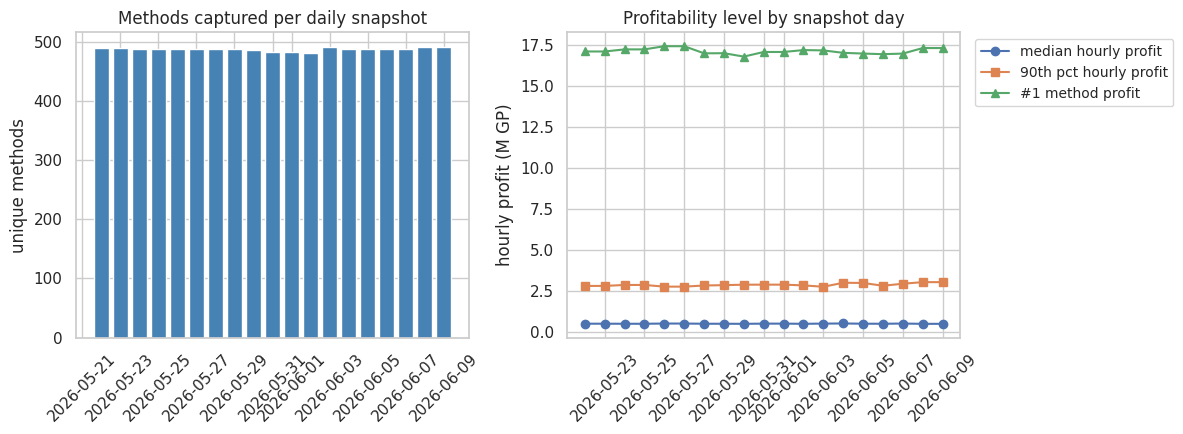

In [3]:
display(panel.dtypes.to_frame("dtype"))
display(
    panel[
        [
            "rank",
            "hourly_profit_gp",
            "gp_per_completion",
            "completions_per_hour",
            "hourly_profit_delta",
            "rank_delta",
            "days_seen",
        ]
    ].describe().T
)

daily_coverage = (
    panel.groupby("snapshot_date", as_index=False)
    .agg(
        methods=("method_id", "nunique"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        p90_hourly_profit=("hourly_profit_gp", lambda s: s.quantile(0.9)),
        top_method_profit=("hourly_profit_gp", "max"),
    )
    .sort_values("snapshot_date")
)
print("Daily scrape coverage:")
display(daily_coverage)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(daily_coverage["snapshot_date"], daily_coverage["methods"], color="steelblue")
axes[0].set_title("Methods captured per daily snapshot")
axes[0].set_ylabel("unique methods")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["median_hourly_profit"] / 1_000_000,
    marker="o",
    label="median hourly profit",
)
axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["p90_hourly_profit"] / 1_000_000,
    marker="s",
    label="90th pct hourly profit",
)
axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["top_method_profit"] / 1_000_000,
    marker="^",
    label="#1 method profit",
)
axes[1].set_title("Profitability level by snapshot day")
axes[1].set_ylabel("hourly profit (M GP)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### Univariate readout

The wiki scrape tracks roughly **500** money-making methods each day. Leaderboard rank is wiki-assigned (lower = more profitable). Day-over-day transitions below use only methods that appear on **consecutive** snapshot dates.

## 2 — Univariate: persistence, profit spread, and rank mobility

How long methods stay in the daily scrape:


,days_seen,methods
0,1,1
1,2,3
2,3,3
3,4,3
4,5,1
5,6,1
6,7,2
7,8,2
8,9,1
9,10,1


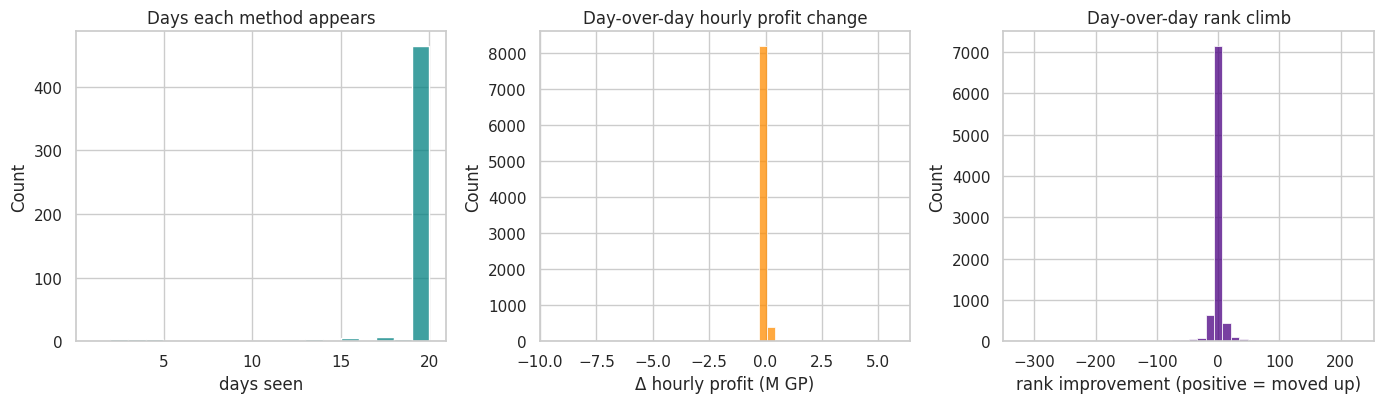

Single-day hourly profit change tiers (day-over-day transitions):
hourly_profit_delta
−500k–0      6372
0–500k       2264
≤−500k         54
500k–1.5M      46
1.5M+          15


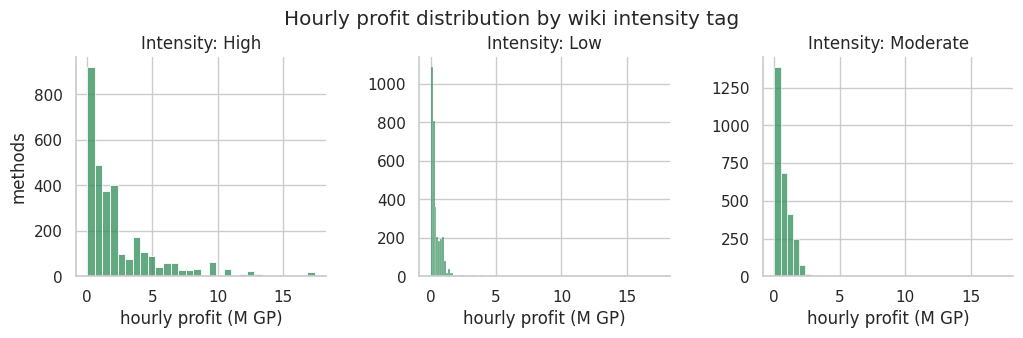

In [4]:
days_on_board = panel.groupby("method_id").size()
persistence = days_on_board.value_counts().sort_index().rename_axis("days_seen").reset_index(name="methods")
print("How long methods stay in the daily scrape:")
display(persistence.head(10))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
sns.histplot(days_on_board, bins=range(1, int(days_on_board.max()) + 2), ax=axes[0], color="teal")
axes[0].set_title("Days each method appears")
axes[0].set_xlabel("days seen")

sns.histplot(
    transitions["hourly_profit_delta"].dropna() / 1_000_000,
    bins=40,
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Day-over-day hourly profit change")
axes[1].set_xlabel("Δ hourly profit (M GP)")

sns.histplot(transitions["rank_improvement"].dropna(), bins=40, ax=axes[2], color="indigo")
axes[2].set_title("Day-over-day rank climb")
axes[2].set_xlabel("rank improvement (positive = moved up)")
fig.tight_layout()
plt.show()

profit_tiers = pd.cut(
    transitions["hourly_profit_delta"],
    bins=[-np.inf, -500_000, 0, 500_000, 1_500_000, np.inf],
    labels=["≤−500k", "−500k–0", "0–500k", "500k–1.5M", "1.5M+"],
)
print("Single-day hourly profit change tiers (day-over-day transitions):")
print(profit_tiers.value_counts().to_string())

g = sns.FacetGrid(
    panel,
    col="intensity",
    col_order=sorted(panel["intensity"].unique()),
    height=3.3,
    aspect=1.05,
    sharex=True,
    sharey=False,
)
g.map_dataframe(sns.histplot, x="hourly_profit_m", bins=30, color="seagreen")
g.set_axis_labels("hourly profit (M GP)", "methods")
g.set_titles(col_template="Intensity: {col_name}")
g.fig.suptitle("Hourly profit distribution by wiki intensity tag", y=1.02)
plt.show()

## 3 — Multivariate: leaderboard, trajectories, and category patterns

Top 15 methods on 2026-06-09 (wiki rank):


,method_id,rank,method_name,primary_category,intensity,hourly_profit_gp,gp_per_completion,completions_per_hour,is_members
0,d0a256b15104f393,1,Killing the Doom of Mokhaiotl (Delve 1-16),Combat,High,"17,300,000","17,203,476",2.5,True
1,d87993968d856ecd,2,Smithing oathplate armour,Skilling,Moderate,"13,977,000","12,570,296",4.0,True
2,3a628916d03de1b0,3,"Killing Yama (Contract of shard acquisition, duo)",Combat,High,"13,248,000","13,644,110",11.0,True
3,44dd5c6cd8c9e556,4,Killing The Doom of Mokhaiotl (Delve 1-8),Combat,High,"12,856,000","12,797,014",6.0,True
4,d5fb2972cd6709e1,5,Completing the Fortis Colosseum (Wave 12),Combat,High,"11,844,000","11,843,729",2.5,True
5,0ca79fb1ab95cb3b,6,Theatre of Blood,Combat,High,"10,773,000","10,720,780",3.0,True
6,b0135e283e71183b,7,Killing Nex (Duo),Combat,High,"10,739,000","10,731,623",6.0,True
7,28e8a3206207cf16,8,Killing Phosani's Nightmare,Combat,High,"9,571,000","9,465,340",10.0,True
8,ee8504ae2cf4c433,9,Tombs of Amascut (solo 545 raid level),Combat,High,"9,563,000","9,469,736",1.7,True
9,994268e9058fe1e5,10,Chambers of Xeric (Challenge Mode),Combat,High,"9,445,000","9,444,504",1.7,True


Top 12 single-day hourly profit surges:


,snapshot_date,method_name,primary_category,rank,hourly_profit_gp,hourly_profit_delta,rank_improvement,gp_per_completion_delta
0,2026-06-08 00:00:00,Smithing oathplate armour,Skilling,2,"13,977,000","+5,665,000",11.000000,"+5,665,168"
1,2026-06-06 00:00:00,Smithing oathplate armour,Skilling,7,"9,815,000","+4,592,000",16.000000,"+4,592,268"
2,2026-05-29 00:00:00,Creating crystal keys,Processing,34,"4,225,000","+3,040,000",92.000000,"+3,040,000"
3,2026-05-24 00:00:00,Crafting aether runes using scarred extract,Skilling,30,"4,717,000","+2,749,000",43.000000,"+2,749,507"
4,2026-05-30 00:00:00,Smithing oathplate armour,Skilling,10,"8,752,000","+2,619,000",8.000000,"+2,619,308"
5,2026-06-03 00:00:00,Killing Phosani's Nightmare,Combat,9,"9,606,000","+2,406,000",5.000000,"+2,406,412"
6,2026-06-07 00:00:00,Fletching gem-tipped dragon bolts,Skilling,52,"2,646,000","+2,241,000",227.000000,"+2,241,000"
7,2026-06-04 00:00:00,Creating crystal keys,Processing,35,"4,115,000","+2,180,000",37.000000,"+2,180,000"
8,2026-06-08 00:00:00,Crafting aether runes using scarred extract,Skilling,42,"3,664,000","+1,933,000",45.000000,"+1,932,462"
9,2026-05-26 00:00:00,Degriming grimy cadantine,Skilling,53,"2,609,000","+1,817,000",138.000000,"+1,816,800"


Top 12 cumulative hourly profit gain across tracked days:


,method_name,primary_category,days_seen,first_hourly_profit,last_hourly_profit,total_profit_gain,best_rank,max_single_day_gain
14,Forging Giant swords,Skilling,19,"172,000","171,000","+4,294,966,296",377,"+1,000"
189,Picking potatoes,Collecting,3,"16,000","15,000","+4,294,966,296",487,+0
190,Killing chaos dwarves,Combat,19,"66,000","65,000","+4,294,966,296",438,"+1,000"
199,Collecting steel platebodies,Collecting,19,"238,000","237,000","+4,294,966,296",330,"+5,000"
217,Killing ogress warriors,Combat,19,"85,000","84,000","+4,294,966,296",430,"+1,000"
240,Killing ogress shamans,Combat,19,"144,000","143,000","+4,294,966,296",398,"+1,000"
253,Collecting ashes,Collecting,19,"35,000","34,000","+4,294,966,296",462,"+2,000"
296,Mining adamantite ore,Skilling,19,"105,000","104,000","+4,294,966,296",419,"+1,000"
459,Killing bears,Combat,19,"17,000","16,000","+4,294,966,296",480,"+1,000"
45,Killing chaos druids,Combat,19,"132,000","130,000","+4,294,965,296",405,"+1,000"


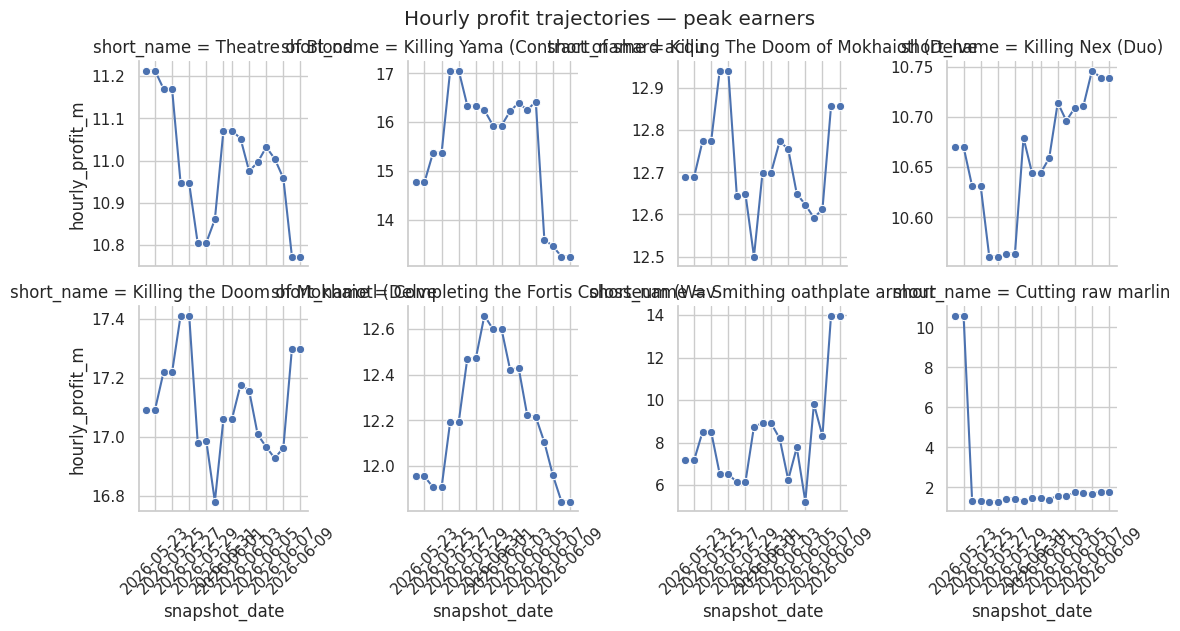

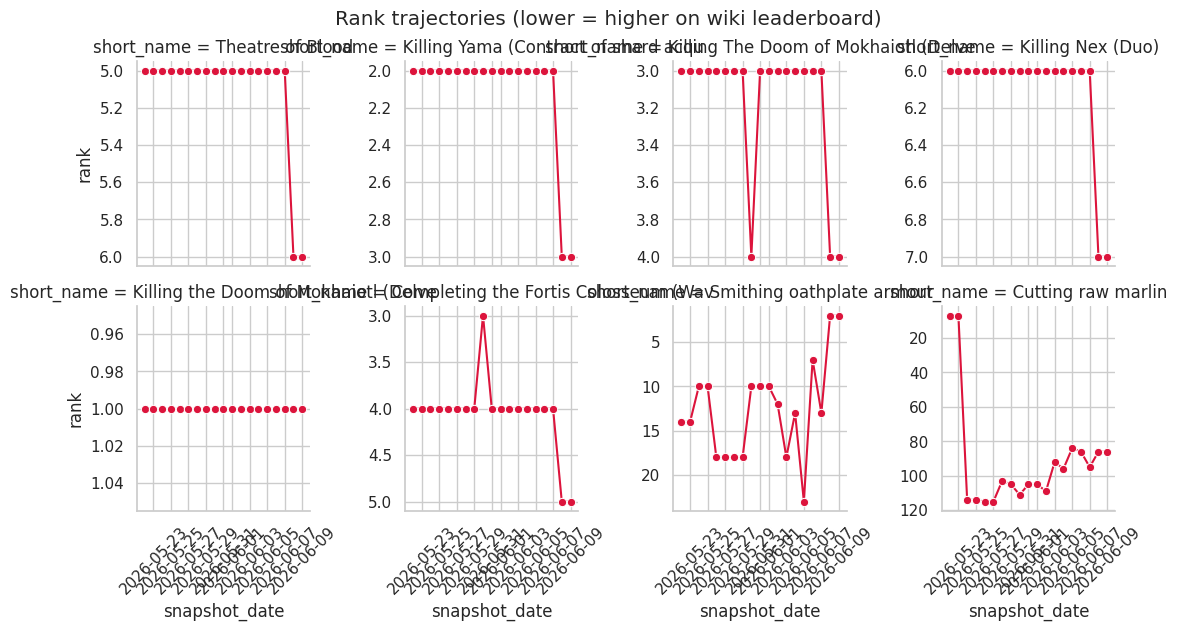

In [5]:
latest_date = panel["snapshot_date"].max()
latest_board = (
    panel.loc[panel["snapshot_date"] == latest_date]
    .sort_values("rank")
    .head(TOP_RANK_BOARD)[
        [
            "method_id",
            "rank",
            "method_name",
            "primary_category",
            "intensity",
            "hourly_profit_gp",
            "gp_per_completion",
            "completions_per_hour",
            "is_members",
        ]
    ]
    .reset_index(drop=True)
)
print(f"Top {TOP_RANK_BOARD} methods on {latest_date.date()} (wiki rank):")
display(latest_board.style.format(
    {
        "hourly_profit_gp": "{:,.0f}",
        "gp_per_completion": "{:,.0f}",
        "completions_per_hour": "{:,.1f}",
    }
))

lifecycle = (
    panel.groupby("method_id", as_index=False)
    .agg(
        method_name=("method_name", "first"),
        primary_category=("primary_category", "first"),
        first_date=("snapshot_date", "min"),
        last_date=("snapshot_date", "max"),
        days_seen=("snapshot_date", "nunique"),
        first_rank=("rank", "first"),
        last_rank=("rank", "last"),
        best_rank=("rank", "min"),
        first_hourly_profit=("hourly_profit_gp", "first"),
        last_hourly_profit=("hourly_profit_gp", "last"),
        peak_hourly_profit=("hourly_profit_gp", "max"),
        max_single_day_gain=("hourly_profit_delta", "max"),
        max_rank_climb=("rank_improvement", "max"),
    )
)
lifecycle["total_profit_gain"] = lifecycle["last_hourly_profit"] - lifecycle["first_hourly_profit"]
lifecycle["net_rank_move"] = lifecycle["first_rank"] - lifecycle["last_rank"]

top_surges = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[
    [
        "snapshot_date",
        "method_name",
        "primary_category",
        "rank",
        "hourly_profit_gp",
        "hourly_profit_delta",
        "rank_improvement",
        "gp_per_completion_delta",
    ]
].reset_index(drop=True)
print(f"Top {TOP_TABLE} single-day hourly profit surges:")
display(top_surges.style.format(
    {
        "hourly_profit_gp": "{:,.0f}",
        "hourly_profit_delta": "{:+,.0f}",
        "gp_per_completion_delta": "{:+,.0f}",
    }
))

top_lifecycle = lifecycle.nlargest(TOP_TABLE, "total_profit_gain")[
    [
        "method_name",
        "primary_category",
        "days_seen",
        "first_hourly_profit",
        "last_hourly_profit",
        "total_profit_gain",
        "best_rank",
        "max_single_day_gain",
    ]
]
print(f"Top {TOP_TABLE} cumulative hourly profit gain across tracked days:")
display(top_lifecycle.style.format(
    {
        "first_hourly_profit": "{:,.0f}",
        "last_hourly_profit": "{:,.0f}",
        "total_profit_gain": "{:+,.0f}",
        "max_single_day_gain": "{:+,.0f}",
    }
))

traj_ids = lifecycle.nlargest(TOP_TRAJECTORIES, "peak_hourly_profit")["method_id"].tolist()
traj = panel.loc[panel["method_id"].isin(traj_ids)].copy()
traj["short_name"] = traj["method_name"].str.slice(0, 36)

g = sns.FacetGrid(traj, col="short_name", col_wrap=4, height=2.8, sharex=True, sharey=False)
g.map_dataframe(sns.lineplot, x="snapshot_date", y="hourly_profit_m", marker="o")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Hourly profit trajectories — peak earners", y=1.02)
plt.show()

g2 = sns.FacetGrid(traj, col="short_name", col_wrap=4, height=2.8, sharex=True, sharey=False)
g2.map_dataframe(sns.lineplot, x="snapshot_date", y="rank", marker="o", color="crimson")
for ax in g2.axes.flat:
    ax.invert_yaxis()
    ax.tick_params(axis="x", rotation=45)
g2.fig.suptitle("Rank trajectories (lower = higher on wiki leaderboard)", y=1.02)
plt.show()

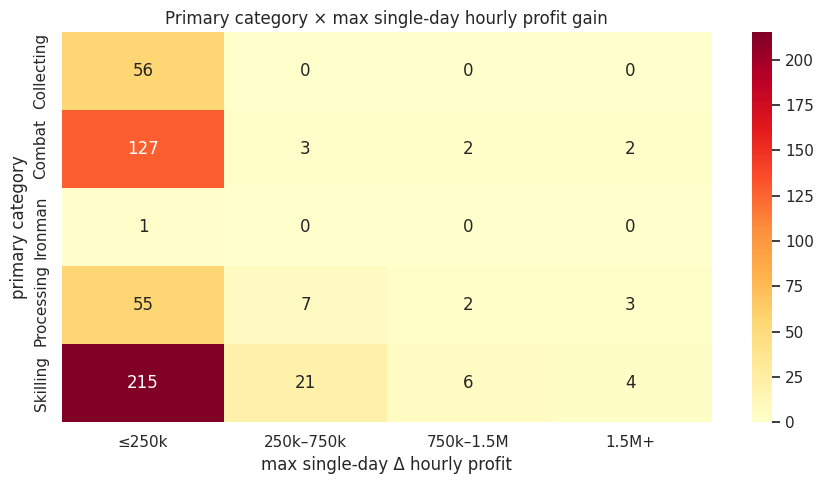

Median hourly profit (GP) by category × intensity:


intensity,High,Low,Moderate
primary_category,,,
Collecting,"142,000","220,000","203,000"
Combat,"3,590,500","336,000","529,000"
Ironman,nan,nan,"1,028,000"
Processing,"1,279,000","700,000","630,000"
Skilling,"775,000","223,500","542,000"


Δ hourly profit vs rank climb: Spearman rho=0.596, p=0


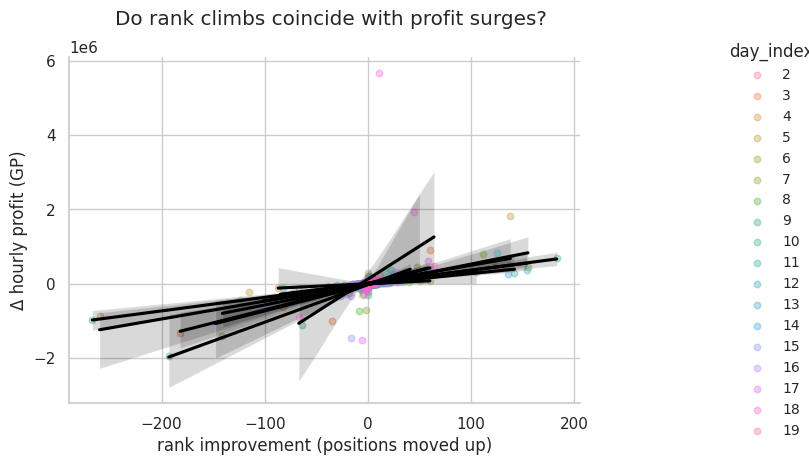

In [6]:
cat_top = (
    lifecycle["primary_category"].value_counts().head(8).index.tolist()
    if lifecycle["primary_category"].nunique() > 8
    else lifecycle["primary_category"].unique().tolist()
)
lifecycle["category_top"] = lifecycle["primary_category"].where(
    lifecycle["primary_category"].isin(cat_top), other="other"
)
lifecycle["surge_bucket"] = pd.cut(
    lifecycle["max_single_day_gain"],
    bins=[-np.inf, 250_000, 750_000, 1_500_000, np.inf],
    labels=["≤250k", "250k–750k", "750k–1.5M", "1.5M+"],
)

ct = pd.crosstab(lifecycle["category_top"], lifecycle["surge_bucket"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Primary category × max single-day hourly profit gain")
ax.set_xlabel("max single-day Δ hourly profit")
ax.set_ylabel("primary category")
plt.tight_layout()
plt.show()

category_medians = (
    panel.groupby(["primary_category", "intensity"], as_index=False)["hourly_profit_gp"]
    .median()
    .pivot(index="primary_category", columns="intensity", values="hourly_profit_gp")
    .sort_index()
)
print("Median hourly profit (GP) by category × intensity:")
display(category_medians.style.format("{:,.0f}").background_gradient(cmap="YlGn", axis=None))

trans_plot = transitions.dropna(subset=["hourly_profit_delta", "rank_improvement"])
rho_profit_rank, p_profit_rank = stats.spearmanr(
    trans_plot["hourly_profit_delta"], trans_plot["rank_improvement"]
)
print(f"Δ hourly profit vs rank climb: Spearman rho={rho_profit_rank:.3f}, p={p_profit_rank:.4g}")

g_lm = sns.lmplot(
    data=trans_plot.sample(min(1500, len(trans_plot)), random_state=7),
    x="rank_improvement",
    y="hourly_profit_delta",
    hue="day_index",
    height=4.5,
    aspect=1.35,
    scatter_kws={"alpha": 0.35, "s": 22},
    line_kws={"color": "black"},
    legend=True,
)
g_lm.set_axis_labels("rank improvement (positions moved up)", "Δ hourly profit (GP)")
g_lm.fig.suptitle("Do rank climbs coincide with profit surges?", y=1.03)
g_lm._legend.set_bbox_to_anchor((1.02, 0.5))
g_lm._legend.set_loc("center left")
plt.show()

## 4 — Profit drivers: GP/completion vs throughput

GP/completion vs hourly profit: Spearman rho=1.000, p=0
Completions/hour vs hourly profit: Spearman rho=-0.337, p=1.156e-242


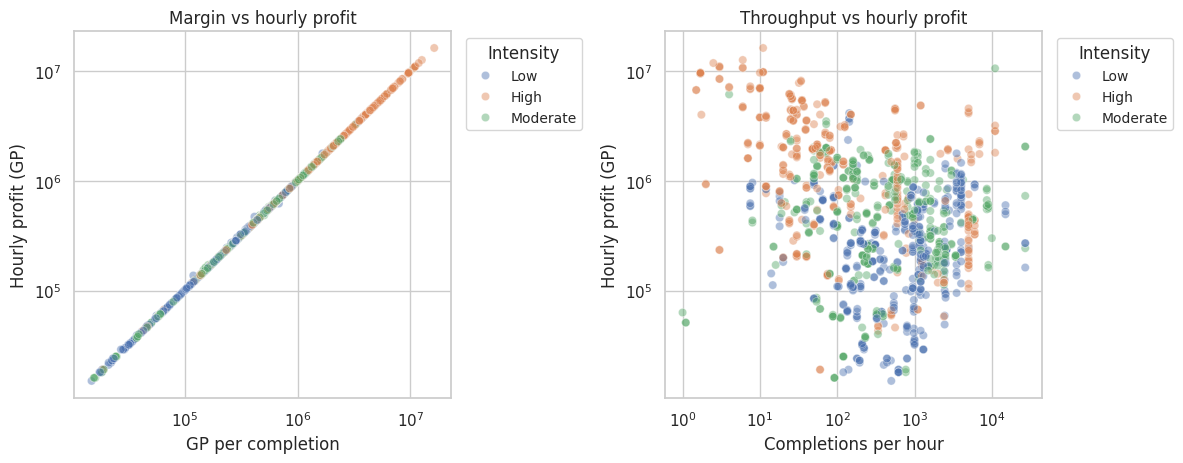

Largest single-day profit jumps — dominant driver (margin vs throughput):


,snapshot_date,method_name,hourly_profit_delta,gp_per_completion_delta,completions_per_hour_delta,profit_driver
0,2026-05-26 00:00:00,Degriming grimy cadantine,"+1,817,000","+1,816,800",+0.0,margin
1,2026-06-03 00:00:00,Killing Phosani's Nightmare,"+2,406,000","+2,406,412",+2.5,margin
2,2026-05-24 00:00:00,Crafting aether runes using scarred extract,"+2,749,000","+2,749,507",+0.0,margin
3,2026-06-08 00:00:00,Crafting aether runes using scarred extract,"+1,933,000","+1,932,462",+0.0,margin
4,2026-06-07 00:00:00,Dismantling bracelets of ethereum,"+1,806,000","+1,806,000",+0.0,margin
5,2026-06-07 00:00:00,Fletching gem-tipped dragon bolts,"+2,241,000","+2,241,000",+0.0,margin
6,2026-05-29 00:00:00,Creating crystal keys,"+3,040,000","+3,040,000",+0.0,margin
7,2026-06-04 00:00:00,Creating crystal keys,"+2,180,000","+2,180,000",+0.0,margin
8,2026-06-07 00:00:00,Creating crystal keys,"+1,755,000","+1,755,000",+0.0,margin
9,2026-05-30 00:00:00,Smithing oathplate armour,"+2,619,000","+2,619,308",+0.0,margin


In [7]:
panel["implied_hourly_profit"] = panel["gp_per_completion"] * panel["completions_per_hour"]
panel["throughput_share"] = panel["completions_per_hour"] / panel.groupby("snapshot_date")[
    "completions_per_hour"
].transform("max")

driver_sample = panel.dropna(subset=["hourly_profit_gp", "gp_per_completion", "completions_per_hour"])
rho_gp, p_gp = stats.spearmanr(driver_sample["gp_per_completion"], driver_sample["hourly_profit_gp"])
rho_kph, p_kph = stats.spearmanr(driver_sample["completions_per_hour"], driver_sample["hourly_profit_gp"])
print(f"GP/completion vs hourly profit: Spearman rho={rho_gp:.3f}, p={p_gp:.4g}")
print(f"Completions/hour vs hourly profit: Spearman rho={rho_kph:.3f}, p={p_kph:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=driver_sample.sample(min(1200, len(driver_sample)), random_state=3),
    x="gp_per_completion",
    y="hourly_profit_gp",
    hue="intensity",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("GP per completion")
axes[0].set_ylabel("Hourly profit (GP)")
axes[0].set_title("Margin vs hourly profit")
axes[0].legend(title="Intensity", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=driver_sample.sample(min(1200, len(driver_sample)), random_state=3),
    x="completions_per_hour",
    y="hourly_profit_gp",
    hue="intensity",
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Completions per hour")
axes[1].set_ylabel("Hourly profit (GP)")
axes[1].set_title("Throughput vs hourly profit")
axes[1].legend(title="Intensity", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

top_movers = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[["method_id", "snapshot_date"]]
mover_panel = panel.merge(top_movers, on=["method_id", "snapshot_date"])
mover_panel["profit_driver"] = np.where(
    mover_panel["gp_per_completion_delta"].abs() >= mover_panel["completions_per_hour_delta"].abs(),
    "margin",
    "throughput",
)
print("Largest single-day profit jumps — dominant driver (margin vs throughput):")
display(
    mover_panel[
        [
            "snapshot_date",
            "method_name",
            "hourly_profit_delta",
            "gp_per_completion_delta",
            "completions_per_hour_delta",
            "profit_driver",
        ]
    ].style.format(
        {
            "hourly_profit_delta": "{:+,.0f}",
            "gp_per_completion_delta": "{:+,.0f}",
            "completions_per_hour_delta": "{:+,.1f}",
        }
    )
)

## 5 — GE price moves for items tied to top profit swings

Item price moves on the biggest method profit surge days (signed by I/O type):


,snapshot_date,method_name,item_name,io_type,qty_per_completion,price_p50,price_p50_delta,profit_impact_proxy,price_variance,volume
13,2026-05-30 00:00:00,Smithing oathplate armour,Oathplate legs,output,1.000,"90,151,473","+591,060","+591,060","162,312,771,860",435
68,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate chest,output,1.000,"92,180,497","+563,636","+563,636","836,393,169,977",530
51,2026-06-06 00:00:00,Smithing oathplate armour,Oathplate shards,input,450.000,"192,552",-610,"+274,612","410,471","29,701"
69,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate legs,output,1.000,"91,830,584","+264,892","+264,892","606,985,561,235",460
12,2026-05-30 00:00:00,Smithing oathplate armour,Oathplate chest,output,1.000,"90,467,723","+149,976","+149,976","238,131,840,388",450
70,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate shards,input,450.000,"191,302",-279,"+125,550","1,346,334","43,050"
62,2026-06-08 00:00:00,Crafting aether runes using scarred extract,Aether catalyst,input,"3,819.200",354,-20,"+75,429",9,"3,587,658"
29,2026-06-03 00:00:00,Killing Phosani's Nightmare,Inquisitor's mace,output,0.001,"314,796,257","+3,379,902","+2,704","5,062,477,678,613",132
6,2026-05-26 00:00:00,Degriming grimy cadantine,Grimy cadantine,input,27.000,"3,010",-96,"+2,606","3,285","420,401"
1,2026-05-24 00:00:00,Crafting aether runes using scarred extract,Aether rune,output,37.200,842,+44,"+1,655",52,"4,918,929"


Highest median GE price variance among items in the current top 15:


,method_name,item_name,io_type,median_variance,median_volume,median_price
234,Killing Phosani's Nightmare,Harmonised orb,output,"5,956,107,485,568",66,"225,854,021"
230,Killing Phosani's Nightmare,Eldritch orb,output,"5,858,368,521,083",85,"225,953,576"
103,Chambers of Xeric (Normal Mode),Twisted bow,output,"5,543,006,353,518",238,"1,556,063,970"
48,Chambers of Xeric (Challenge Mode),Twisted bow,output,"5,543,006,353,518",238,"1,556,063,970"
237,Killing Phosani's Nightmare,Inquisitor's mace,output,"5,250,664,819,389",136,"311,416,356"
210,Killing Nex (Team),Nihil horn,output,"1,810,206,161,158",19,"320,839,722"
184,Killing Nex (Duo),Nihil horn,output,"1,810,206,161,158",19,"320,839,722"
332,Killing the Doom of Mokhaiotl (Delve 1-16),Avernic treads,output,"1,106,835,287,479",472,"178,199,430"
254,Killing The Doom of Mokhaiotl (Delve 1-8),Avernic treads,output,"1,106,835,287,479",472,"178,199,430"
238,Killing Phosani's Nightmare,Inquisitor's plateskirt,output,"709,393,097,703",110,"90,625,000"


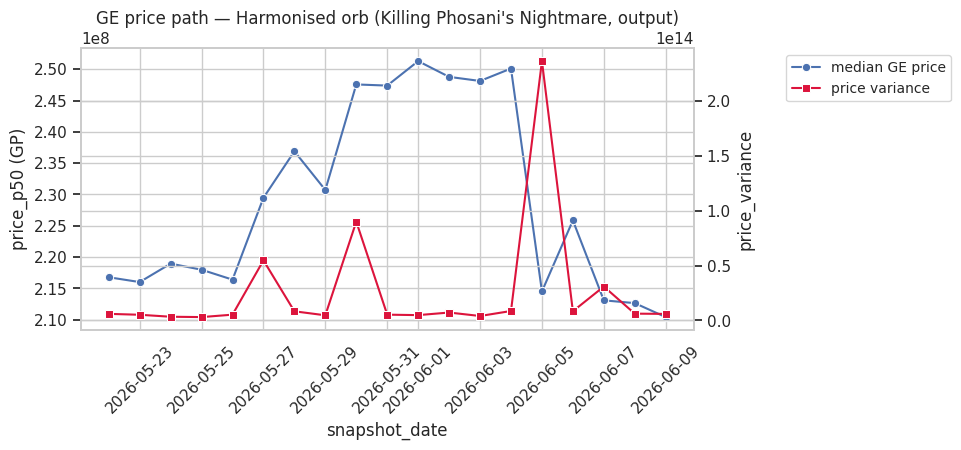

In [8]:
io_prices = io_lines.dropna(subset=["item_id"]).copy()
io_prices["item_id"] = io_prices["item_id"].astype(int)

price_long = prices.loc[prices["metric"].isin(["price_p50", "price_variance", "volume"])].copy()
price_wide = (
    price_long.pivot_table(
        index=["item_id", "snapshot_date"],
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["item_id", "snapshot_date"])
)
price_wide["price_p50_delta"] = price_wide.groupby("item_id")["price_p50"].diff()

io_price = io_prices.merge(price_wide, on="item_id", how="inner", validate="m:m")
io_price = io_price.merge(
    methods[["method_id", "method_name"]], on="method_id", how="left", validate="m:1"
)

surge_keys = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[["method_id", "snapshot_date"]]
surge_items = io_price.merge(surge_keys, on=["method_id", "snapshot_date"])
surge_items["signed_price_delta"] = np.where(
    surge_items["io_type"] == "input",
    -surge_items["price_p50_delta"],
    surge_items["price_p50_delta"],
)
surge_items["profit_impact_proxy"] = surge_items["signed_price_delta"] * surge_items["qty_per_completion"]

item_moves = (
    surge_items.groupby(
        ["snapshot_date", "method_name", "item_name", "io_type"], as_index=False
    )
    .agg(
        qty_per_completion=("qty_per_completion", "first"),
        price_p50=("price_p50", "first"),
        price_p50_delta=("price_p50_delta", "first"),
        profit_impact_proxy=("profit_impact_proxy", "first"),
        price_variance=("price_variance", "first"),
        volume=("volume", "first"),
    )
    .sort_values("profit_impact_proxy", ascending=False)
)
print("Item price moves on the biggest method profit surge days (signed by I/O type):")
display(
    item_moves.head(TOP_TABLE).style.format(
        {
            "qty_per_completion": "{:,.3f}",
            "price_p50": "{:,.0f}",
            "price_p50_delta": "{:+,.0f}",
            "profit_impact_proxy": "{:+,.0f}",
            "price_variance": "{:,.0f}",
            "volume": "{:,.0f}",
        }
    )
)

top_board_ids = latest_board["method_id"].tolist()
board_items = io_price.loc[io_price["method_id"].isin(top_board_ids)].copy()
vol_summary = (
    board_items.groupby(["method_name", "item_name", "io_type"], as_index=False)
    .agg(
        median_variance=("price_variance", "median"),
        median_volume=("volume", "median"),
        median_price=("price_p50", "median"),
    )
    .sort_values("median_variance", ascending=False)
)
print(f"Highest median GE price variance among items in the current top {TOP_RANK_BOARD}:")
display(
    vol_summary.head(TOP_TABLE).style.format(
        {
            "median_variance": "{:,.0f}",
            "median_volume": "{:,.0f}",
            "median_price": "{:,.0f}",
        }
    )
)

volatile_item = vol_summary.iloc[0]
item_ts = board_items.loc[board_items["item_name"] == volatile_item["item_name"]].drop_duplicates(
    subset=["snapshot_date"]
)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=item_ts, x="snapshot_date", y="price_p50", marker="o", ax=ax, label="median GE price")
ax2 = ax.twinx()
sns.lineplot(
    data=item_ts,
    x="snapshot_date",
    y="price_variance",
    marker="s",
    color="crimson",
    ax=ax2,
    label="price variance",
)
ax.set_title(
    f"GE price path — {volatile_item['item_name']} ({volatile_item['method_name']}, {volatile_item['io_type']})"
)
ax.set_ylabel("price_p50 (GP)")
ax2.set_ylabel("price_variance")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.14, 1), loc="upper left")
ax2.get_legend().remove()
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

In [9]:
big_surge = transitions.loc[transitions["hourly_profit_delta"] >= 1_500_000]
surge_by_day = (
    transitions.groupby("snapshot_date")
    .agg(
        transitions=("method_id", "count"),
        median_gain=("hourly_profit_delta", "median"),
        big_surges=("hourly_profit_delta", lambda s: (s >= 1_500_000).sum()),
    )
    .reset_index()
)

stable_top = (
    panel.loc[panel["rank"] <= TOP_RANK_BOARD]
    .groupby("method_id")
    .agg(
        days_in_top=("snapshot_date", "nunique"),
        avg_rank=("rank", "mean"),
        method_name=("method_name", "first"),
    )
    .sort_values(["days_in_top", "avg_rank"], ascending=[False, True])
)

print("=== Top money makers summary ===")
print(
    f"Daily snapshots: {panel['snapshot_date'].nunique()} days, "
    f"{methods.shape[0]:,} methods in entity table"
)
print(
    f"Methods tracked 2+ days: {(days_on_board >= 2).sum():,} "
    f"({(days_on_board >= 2).mean() * 100:.1f}% of seen methods)"
)
print(f"Day-over-day transitions: {len(transitions):,}")
print(
    f"Transitions with ≥1.5M GP/h profit gain: {len(big_surge):,} "
    f"({len(big_surge) / len(transitions) * 100:.2f}%)"
)
print(f"Median Δ hourly profit on transition days: {transitions['hourly_profit_delta'].median():,.0f} GP")
print(f"Median rank improvement: {transitions['rank_improvement'].median():.0f} positions")
print()
print(f"Current #1 method ({latest_date.date()}):")
leader = latest_board.iloc[0]
print(
    f"  {leader['method_name']}\n"
    f"  {leader['hourly_profit_gp']:,.0f} GP/h | rank #{leader['rank']:.0f} | "
    f"{leader['gp_per_completion']:,.0f} GP/completion × {leader['completions_per_hour']:.1f}/h"
)
print()
print("Most persistent top-15 methods (days spent in top ranks):")
print(stable_top.head(5).to_string(index=False))
print()
print("Busiest surge days (≥1.5M GP/h jumps):")
print(surge_by_day.sort_values("big_surges", ascending=False).head(5).to_string(index=False))
print()
print("Biggest single-day profit surge:")
row = transitions.loc[transitions["hourly_profit_delta"].idxmax()]
print(
    f"  {row['method_name']}\n"
    f"  +{row['hourly_profit_delta']:,.0f} GP/h on {row['snapshot_date'].date()}, "
    f"rank #{row['rank']:.0f}"
)
print()
print(
    "Takeaway: the wiki leaderboard is dominated by high-margin PvM and raid methods — "
    "hourly profit moves mainly through GP/completion shifts rather than throughput tweaks. "
    "GE item prices for linked inputs/outputs explain part of the day-over-day swings, "
    "especially on volatile rare drops; rank and profit usually move together but "
    "multi-day persistence in the top 15 separates stable grinds from one-day spikes."
)

=== Top money makers summary ===
Daily snapshots: 19 days, 505 methods in entity table
Methods tracked 2+ days: 504 (99.8% of seen methods)
Day-over-day transitions: 8,751
Transitions with ≥1.5M GP/h profit gain: 15 (0.17%)
Median Δ hourly profit on transition days: 0 GP
Median rank improvement: -0 positions

Current #1 method (2026-06-09):
  Killing the Doom of Mokhaiotl (Delve 1-16)
  17,300,000 GP/h | rank #1 | 17,203,476 GP/completion × 2.5/h

Most persistent top-15 methods (days spent in top ranks):
 days_in_top  avg_rank                                       method_name
          19  1.000000        Killing the Doom of Mokhaiotl (Delve 1-16)
          19  2.105263 Killing Yama (Contract of shard acquisition, duo)
          19  3.157895         Killing The Doom of Mokhaiotl (Delve 1-8)
          19  4.052632         Completing the Fortis Colosseum (Wave 12)
          19  5.105263                                  Theatre of Blood

Busiest surge days (≥1.5M GP/h jumps):
snapshot_dat